In [1]:

#%% Run to have everything 

import torch
from numpy import random
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../tgv_pycuda-master"))
sys.path.append(os.path.abspath("../tgv_odl_pghd/denoise"))
sys.path.append(os.path.abspath(".."))




from Algo_setuptorch import Params

from data.dataset import build_train_test_data


from NN_every.algorithm.unrolled_model import UnrolledFBS

from training.train import train
from NN_every.plots import *
from NN_every.run import *



from pghd_denoising import pdhg






device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

params = Params()

TRAIN_SEEDS = list(range(50))  
TEST_SEEDS = list(range(50,60))


size = params.size
SHAPES = [
    (1, 1, size, size),
    (1, 2, size, size),
    (1, 2, size, size),
    (1, 3, size, size),
]
N_CH = sum(s[1] for s in SHAPES)
N_CH_primal = sum(s[1] for s in SHAPES[:2])
print("ok")

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)


initial_state, clean, functions = test_data[0]


u_clean = clean.to(device)

x_clean = [
    u_clean,
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 3, size, size), device=device),
]

print(functions["kkt_residual_norm"](x_clean))

Device: cuda
ok
tensor(17.7097, device='cuda:0')


In [5]:
F_vals_0, res_0,x= run_zero(initial_state,functions, params, SHAPES, 50, device)

F_vals_CNN,res_CNN= run_learned(model,initial_state,clean,functions,T_test=50)

#import matplotlib.pyplot as plt

""" img = history["x"][-1][0]

# convertir proprement
img_np = img.detach().cpu().squeeze().numpy()

plt.imsave("final_image.png", img_np, cmap="gray") """

iter:0
17.043291091918945
iter:1
20.942962646484375
iter:2
23.724597930908203
iter:3
24.343429565429688
iter:4
23.54116439819336
iter:5
22.069808959960938
iter:6
20.35031509399414
iter:7
18.709064483642578
iter:8
17.290874481201172
iter:9
16.139400482177734
iter:10
15.231632232666016
iter:11
14.503945350646973
iter:12
13.882665634155273
iter:13
13.316471099853516
iter:14
12.782438278198242
iter:15
12.27737808227539
iter:16
11.80285930633545
iter:17
11.3624906539917
iter:18
10.961307525634766
iter:19
10.601739883422852
iter:20
10.280466079711914
iter:21
9.996779441833496
iter:22
9.742833137512207
iter:23
9.507965087890625
iter:24
9.285231590270996
iter:25
9.070592880249023
iter:26
8.858564376831055
iter:27
8.646574020385742
iter:28
8.435297966003418
iter:29
8.226075172424316
iter:30
8.019937515258789
iter:31
7.816771984100342
iter:32
7.618455410003662
iter:33
7.424637794494629
iter:34
7.236096382141113
iter:35
7.051355838775635
iter:36
6.870456218719482
iter:37
6.693387508392334
iter:38

' img = history["x"][-1][0]\n\n# convertir proprement\nimg_np = img.detach().cpu().squeeze().numpy()\n\nplt.imsave("final_image.png", img_np, cmap="gray") '

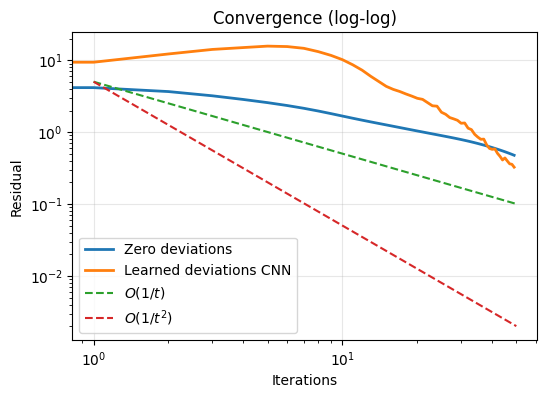

In [6]:

# Convertir en numpy si besoin
res_0 = np.array(res_0)

res_CNN = np.array(res_CNN)
# Axe des itérations 
iters = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6,4))

# Courbes principales

plt.loglog(res_0, label='Zero deviations', linewidth=2)

plt.loglog(res_CNN, label='Learned deviations CNN', linewidth=2)
# Références théoriques
plt.semilogy(iters, res_0[0]/iters, '--', label=r'$O(1/t)$')
plt.semilogy(iters, res_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

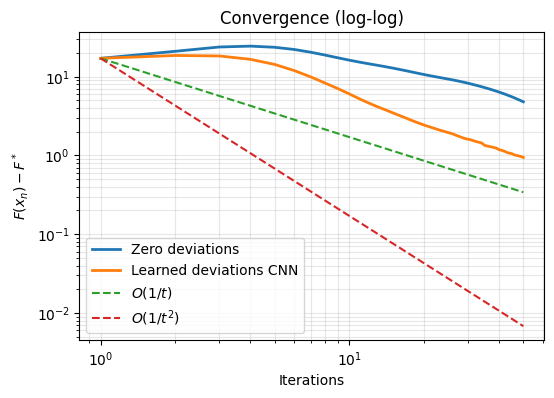

In [7]:
# convertir proprement
F_vals_0 = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_0
])


F_vals_CNN = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_CNN
]) 

# approx de F*

AxCxmin=F_vals_0.min()
# gaps
gap_0 = F_vals_0

gap_CNN=F_vals_CNN
# éviter log(0)
gap_0 = np.maximum(gap_0, 1e-16)

gap_CNN   = np.maximum(gap_CNN,   1e-16)
gap_0 = gap_0[:400]

gap_CNN   =gap_CNN[:400]

iters = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6,4))

plt.loglog(iters, gap_0, label='Zero deviations', linewidth=2)

plt.loglog(iters, gap_CNN,   label='Learned deviations CNN', linewidth=2)
# références
plt.loglog(iters, gap_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, gap_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel(r'$F(x_n) - F^*$')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()